In [1]:
import copy
import collections
import os
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import py3Dmol
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdMolAlign
from rdkit.Chem import PeriodicTable
from rdkit.Chem.Lipinski import RotatableBondSmarts
import scipy
from scipy import spatial as sci_spatial
import torch
from tqdm.auto import tqdm
import seaborn as sns

ptable = Chem.GetPeriodicTable()

/home/phz24002/anaconda3/envs/targetdiff/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')  

In [3]:
import sys, os
sys.path.insert(0, os.path.abspath('../'))

from utils.evaluation import eval_bond_length, scoring_func, similarity

In [4]:
MODEL_NAME = 'TAGMol-VEDA'

# Load Data

In [5]:
class Globals:
    reference_path = 'sampling_results/crossdocked_test_vina_docked.pt'
    pocket2mol_path = 'sampling_results/pocket2mol_vina_docked.pt'
    PAFlow_path = 'sampling_results/PAFlow_results.pt'
    targetdiff_path = 'sampling_results/targetdiff_vina_docked.pt'
    our_path = 'sampling_results/tagmol_veda.pt'
    # tagmol_path = 'sampling_results/.pt'

In [6]:
Globals.reference_results = torch.load(Globals.reference_path)
Globals.reference_results = [[v] for v in Globals.reference_results]
Globals.PAFlow_results = torch.load(Globals.PAFlow_path)
Globals.pocket2mol_results = torch.load(Globals.pocket2mol_path)
Globals.targetdiff_results = torch.load(Globals.targetdiff_path)
Globals.our_results = torch.load(Globals.our_path)

In [7]:
loaded = torch.load(Globals.our_path)

# 1) 先取真正的结果列表
if isinstance(loaded, dict):
    our = loaded.get('all_results', loaded)
else:
    our = loaded

# 2) 统一成“按 pocket 分组”的结构：List[List[dict]]
if isinstance(our, list) and len(our) > 0 and isinstance(our[0], dict):
    from collections import defaultdict
    by_pocket = defaultdict(list)
    for r in our:
        k = r.get('protein_filename') or r.get('ligand_filename') or 'unknown'
        by_pocket[k].append(r)
    Globals.our_results = list(by_pocket.values())
else:
    Globals.our_results = our

# Metrics Summary

In [15]:
def print_results(results, show_vina=True):
    qed = [r['chem_results']['qed'] for r in results]
    sa = [r['chem_results']['sa'] for r in results]
    mol_size = [r['mol'].GetNumAtoms() for r in results]
    print('Num results: %d' % len(results))
    if show_vina:
        vina_score_only = [x['vina']['score_only'][0]['affinity'] for x in results]
        vina_min = [x['vina']['minimize'][0]['affinity'] for x in results]
        vina_dock = [r['vina']['dock'][0]['affinity'] for r in results]
        print('[Vina Score] Avg: %.2f | Med: %.2f' % (np.mean(vina_score_only), np.median(vina_score_only)))
        print('[Vina Min]   Avg: %.2f | Med: %.2f' % (np.mean(vina_min), np.median(vina_min)))
        print('[Vina Dock]  Avg: %.4f | Med: %.4f' % (np.mean(vina_dock), np.median(vina_dock)))
        
    print('[QED]  Avg: %.4f | Med: %.4f' % (np.mean(qed), np.median(qed)))
    print('[SA]   Avg: %.4f | Med: %.4f' % (np.mean(sa), np.median(sa)))
    print('[Size] Avg: %.4f | Med: %.4f' % (np.mean(mol_size), np.median(mol_size)))

def compute_high_affinity(vina_ref, results):
    percentage_good = []
    num_docked = []
    qed_good, sa_good = [], []
    for i in range(100):
        score_ref = vina_ref[i]
        pocket_results = [r for r in results[i] if r['vina'] is not None]
        # if len(pocket_results) < 50:
            # continue
        num_docked.append(len(pocket_results))

        scores_gen = []
        for docked in pocket_results:
            aff = docked['vina']['dock'][0]['affinity']
            scores_gen.append(aff)
            if aff <= score_ref:
                qed_good.append(docked['chem_results']['qed'])
                sa_good.append(docked['chem_results']['sa'])
        scores_gen = np.array(scores_gen)
        percentage_good.append((scores_gen <= score_ref).mean())

    percentage_good = np.array(percentage_good)
    num_docked = np.array(num_docked)

    print('[HF%%]  Avg: %.2f%% | Med: %.2f%% ' % (np.mean(percentage_good)*100, np.median(percentage_good)*100))
    print('[HF-QED]  Avg: %.4f | Med: %.4f ' % (np.mean(qed_good)*100, np.median(qed_good)*100))
    print('[HF-SA]   Avg: %.4f | Med: %.4f ' % (np.mean(sa_good)*100, np.median(sa_good)*100))
    print('[Success%%] %.2f%% ' % (np.mean(percentage_good > 0)*100, ))

## Reference

In [16]:
flat_ref_docked = [r for pr in Globals.reference_results for r in pr]
print_results(flat_ref_docked)

Num results: 100
[Vina Score] Avg: -6.36 | Med: -6.46
[Vina Min]   Avg: -6.71 | Med: -6.49
[Vina Dock]  Avg: -7.4501 | Med: -7.2630
[QED]  Avg: 0.4760 | Med: 0.4676
[SA]   Avg: 0.7277 | Med: 0.7400
[Size] Avg: 22.7500 | Med: 21.5000


In [17]:
vina_ref = [r['vina']['dock'][0]['affinity'] for r in flat_ref_docked]

## PAFlow

In [18]:
flat_paflow_docked = [r for pr in Globals.PAFlow_results for r in pr]
print_results(flat_paflow_docked)
compute_high_affinity(vina_ref, Globals.PAFlow_results)

Num results: 8113
[Vina Score] Avg: -8.31 | Med: -8.92
[Vina Min]   Avg: -8.79 | Med: -8.96
[Vina Dock]  Avg: -9.4553 | Med: -9.4860
[QED]  Avg: 0.4907 | Med: 0.4953
[SA]   Avg: 0.5690 | Med: 0.5700
[Size] Avg: 22.9466 | Med: 23.0000
[HF%]  Avg: 80.81% | Med: 93.72% 
[HF-QED]  Avg: 49.8237 | Med: 50.1058 
[HF-SA]   Avg: 55.8138 | Med: 56.0000 
[Success%] 99.00% 


## Pocket2Mol

In [19]:
flat_p2m_docked = [r for pr in Globals.pocket2mol_results for r in pr]
print_results(flat_p2m_docked)
compute_high_affinity(vina_ref, Globals.pocket2mol_results)

Num results: 9831
[Vina Score] Avg: -5.14 | Med: -4.70
[Vina Min]   Avg: -6.42 | Med: -5.82
[Vina Dock]  Avg: -7.1515 | Med: -6.7850
[QED]  Avg: 0.5729 | Med: 0.5770
[SA]   Avg: 0.7558 | Med: 0.7600
[Size] Avg: 17.7363 | Med: 15.0000
[HF%]  Avg: 48.00% | Med: 51.00% 
[HF-QED]  Avg: 56.5365 | Med: 57.4937 
[HF-SA]   Avg: 72.2879 | Med: 72.0000 
[Success%] 88.00% 


## TargetDiff

In [20]:
flat_targetdiff_docked = [r for pr in Globals.targetdiff_results for r in pr]
print_results(flat_targetdiff_docked)
compute_high_affinity(vina_ref, Globals.targetdiff_results)

Num results: 9036
[Vina Score] Avg: -5.47 | Med: -6.30
[Vina Min]   Avg: -6.64 | Med: -6.83
[Vina Dock]  Avg: -7.8018 | Med: -7.9080
[QED]  Avg: 0.4798 | Med: 0.4808
[SA]   Avg: 0.5846 | Med: 0.5800
[Size] Avg: 24.2371 | Med: 24.0000
[HF%]  Avg: 57.57% | Med: 58.27% 
[HF-QED]  Avg: 49.8315 | Med: 49.9722 
[HF-SA]   Avg: 56.3689 | Med: 56.0000 
[Success%] 99.00% 


## TAGMol-VEDA

In [21]:
flat_ours_docked = [r for pr in Globals.our_results for r in pr]
print_results(flat_ours_docked)
compute_high_affinity(vina_ref, Globals.our_results)

Num results: 945
[Vina Score] Avg: -7.42 | Med: -7.70
[Vina Min]   Avg: 2030649.47 | Med: -7.96
[Vina Dock]  Avg: -8.5327 | Med: -8.7310
[QED]  Avg: 0.6076 | Med: 0.6247
[SA]   Avg: 0.7291 | Med: 0.7200
[Size] Avg: 24.3820 | Med: 25.0000
[HF%]  Avg: 73.97% | Med: 80.00% 
[HF-QED]  Avg: 60.7580 | Med: 62.1590 
[HF-SA]   Avg: 71.1044 | Med: 70.0000 
[Success%] 99.00% 


# Atom Distance

In [22]:
def get_all_atom_distance(results):
    atom_distance_list = []
    for pocket in results:
        for ligand in pocket:
            mol = ligand['mol']
            mol = Chem.RemoveAllHs(mol)
            pos = mol.GetConformers()[0].GetPositions()
            dist = sci_spatial.distance.pdist(pos, metric='euclidean')
            atom_distance_list += dist.tolist()
    return np.array(atom_distance_list)
        
Globals.reference_atom_dist = get_all_atom_distance(Globals.reference_results)
Globals.our_atom_dist = get_all_atom_distance(Globals.our_results)
Globals.paflow_atom_dist = get_all_atom_distance(Globals.PAFlow_results)
Globals.pocket2mol_atom_dist = get_all_atom_distance(Globals.pocket2mol_results)
Globals.targetdiff_atom_dist = get_all_atom_distance(Globals.targetdiff_results)

In [23]:
def get_all_c_c_distance(results):
    c_c_distance_list = []
    for pocket in results:
        for ligand in pocket:
            mol = ligand['mol']
            mol = Chem.RemoveAllHs(mol)
            for bond_type, dist in eval_bond_length.bond_distance_from_mol(mol):
                if bond_type[:2] == (6, 6):
                    c_c_distance_list.append(dist)
    return np.array(c_c_distance_list)

Globals.reference_c_c_dist = get_all_c_c_distance(Globals.reference_results)
Globals.our_c_c_dist = get_all_c_c_distance(Globals.our_results)
Globals.paflow_c_c_dist = get_all_c_c_distance(Globals.PAFlow_results)
Globals.pocket2mol_c_c_dist = get_all_c_c_distance(Globals.pocket2mol_results)
Globals.targetdiff_c_c_dist = get_all_c_c_distance(Globals.targetdiff_results)

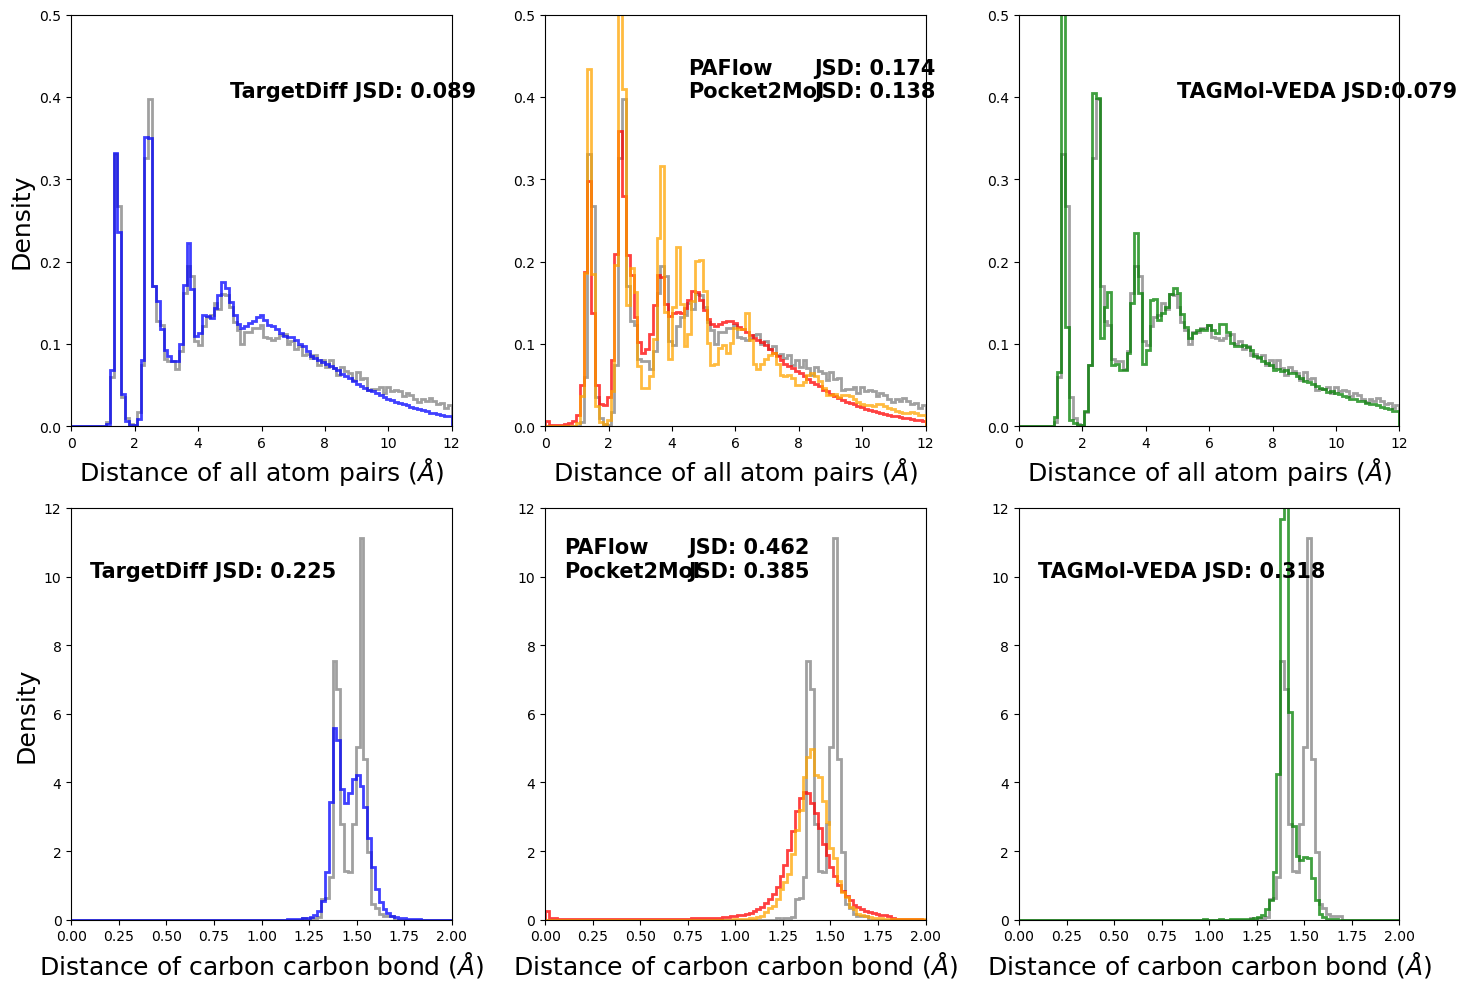

In [24]:
plt.figure(figsize=(15, 10))

LW = 2
LABEL_FONTSIZE = 18
ALPHA = 0.75

BINS = np.linspace(0, 12, 100)
def _plot_other(plot_ylabel=False):
    if plot_ylabel:
        plt.ylabel('Density', fontsize=LABEL_FONTSIZE)
    plt.xlabel('Distance of all atom pairs ($\AA$)', fontsize=LABEL_FONTSIZE)
    plt.ylim(0, 0.5)
    plt.xlim(0, 12)
    
reference_profile = eval_bond_length.get_distribution(Globals.reference_atom_dist, bins=BINS)
def _compute_jsd(atom_dist_list):
    profile = eval_bond_length.get_distribution(atom_dist_list, bins=BINS)
    return sci_spatial.distance.jensenshannon(reference_profile, profile)

ax = plt.subplot(2,3,1)
plt.hist(Globals.reference_atom_dist, bins=BINS, histtype='step', density=True, lw=LW, color='gray', alpha=ALPHA, label='reference')
plt.hist(Globals.targetdiff_atom_dist, bins=BINS, histtype='step', density=True, lw=LW, color='blue', alpha=ALPHA, label='TargetDiff')
jsd = _compute_jsd(Globals.targetdiff_atom_dist)
ax.text(5, 0.4, f'TargetDiff JSD: {jsd:.3f}', fontsize=15, weight='bold')
# plt.title(f'TargetDiff (JSD={jsd:.3f})')
_plot_other(plot_ylabel=True)
ax = plt.subplot(2,3,2)
plt.hist(Globals.reference_atom_dist, bins=BINS, histtype='step', density=True, lw=LW, color='gray', alpha=ALPHA, label='reference')
plt.hist(Globals.paflow_atom_dist, bins=BINS, histtype='step', density=True, lw=LW, color='red', alpha=ALPHA, label='PAFlow')
# jsd = _compute_jsd(Globals.paflow_atom_dist)
plt.hist(Globals.pocket2mol_atom_dist, bins=BINS, histtype='step', density=True, lw=LW, color='orange', alpha=ALPHA, label='Pocket2Mol')
paflow_jsd = _compute_jsd(Globals.paflow_atom_dist)
p2m_jsd = _compute_jsd(Globals.pocket2mol_atom_dist)
ax.text(4.5, 0.4, f'PAFlow\nPocket2Mol', fontsize=15, weight='bold')
ax.text(8.5, 0.4, f'JSD: {paflow_jsd:.3f}\nJSD: {p2m_jsd:.3f}', fontsize=15, weight='bold')
# plt.title(f'AR (JSD={jsd:.3f})')
_plot_other()
ax = plt.subplot(2,3,3)
plt.hist(Globals.reference_atom_dist, bins=BINS, histtype='step', density=True, lw=LW, color='gray', alpha=ALPHA, label='reference')
plt.hist(Globals.our_atom_dist, bins=BINS, histtype='step', density=True, lw=LW, color='green', alpha=ALPHA, label=MODEL_NAME)
jsd = _compute_jsd(Globals.our_atom_dist)
ax.text(5, 0.4, f'{MODEL_NAME} JSD:{jsd:.3f}', fontsize=15, weight='bold')
# plt.title(f'{MODEL_NAME} (JSD={jsd:.3f})')
_plot_other()

BINS = np.linspace(0, 2, 100)

def _select_proximal(arr):
    arr = np.array()

def _plot_other(plot_ylabel=False):
    if plot_ylabel:
        plt.ylabel('Density', fontsize=LABEL_FONTSIZE)
    plt.xlabel('Distance of carbon carbon bond ($\AA$)', fontsize=LABEL_FONTSIZE)
    plt.ylim(0, 12)
    plt.xlim(0, 2)
    
reference_profile = eval_bond_length.get_distribution(Globals.reference_c_c_dist, bins=BINS)
def _compute_jsd(atom_dist_list):
    profile = eval_bond_length.get_distribution(atom_dist_list, bins=BINS)
    return sci_spatial.distance.jensenshannon(reference_profile, profile)

ax = plt.subplot(2,3,4)
plt.hist(Globals.reference_c_c_dist, bins=BINS, histtype='step', density=True, lw=LW, color='gray', alpha=ALPHA, label='reference')
plt.hist(Globals.targetdiff_c_c_dist, bins=BINS, histtype='step', density=True, lw=LW, color='blue', alpha=ALPHA, label='TargetDiff')
jsd = _compute_jsd(Globals.targetdiff_c_c_dist)
ax.text(0.1, 10, f'TargetDiff JSD: {jsd:.3f}', fontsize=15, weight='bold')
# plt.title(f'TargetDiff (JSD={jsd:.3f})')
_plot_other(plot_ylabel=True)
ax = plt.subplot(2,3,5)
plt.hist(Globals.reference_c_c_dist, bins=BINS, histtype='step', density=True, lw=LW, color='gray', alpha=ALPHA, label='reference')
plt.hist(Globals.paflow_c_c_dist, bins=BINS, histtype='step', density=True, lw=LW, color='red', alpha=ALPHA, label='PAFlow')
plt.hist(Globals.pocket2mol_c_c_dist, bins=BINS, histtype='step', density=True, lw=LW, color='orange', alpha=ALPHA, label='Pocket2Mol')
paflow_jsd = _compute_jsd(Globals.paflow_c_c_dist)
p2m_jsd = _compute_jsd(Globals.pocket2mol_c_c_dist)
ax.text(0.1, 10, f'PAFlow\nPocket2Mol', fontsize=15, weight='bold')
ax.text(0.75, 10, f'JSD: {paflow_jsd:.3f}\nJSD: {p2m_jsd:.3f}', fontsize=15, weight='bold')
# plt.title(f'AR (JSD={jsd:.3f})')
_plot_other()
ax = plt.subplot(2,3,6)
plt.hist(Globals.reference_c_c_dist, bins=BINS, histtype='step', density=True, lw=LW, color='gray', alpha=ALPHA, label='reference')
plt.hist(Globals.our_c_c_dist, bins=BINS, histtype='step', density=True, lw=LW, color='green', alpha=ALPHA, label=MODEL_NAME)
jsd = _compute_jsd(Globals.our_c_c_dist)
ax.text(0.1, 10, f'{MODEL_NAME} JSD: {jsd:.3f}', fontsize=15, weight='bold')
# plt.title(f'{MODEL_NAME} (JSD={jsd:.3f})')
_plot_other()

plt.tight_layout()
# plt.savefig('output_figures/distance_distribution.pdf')
plt.show()

# Bond Distance

In [25]:
def get_bond_length_profile(results):
    bond_distances = []
    for pocket in results:
        for ligand in pocket:
            mol = ligand['mol']
            mol = Chem.RemoveAllHs(mol)
            bond_distances += eval_bond_length.bond_distance_from_mol(mol)
    return eval_bond_length.get_bond_length_profile(bond_distances)

Globals.reference_bond_length_profile = get_bond_length_profile(Globals.reference_results)
Globals.our_bond_length_profile = get_bond_length_profile(Globals.our_results)
Globals.paflow_bond_length_profile = get_bond_length_profile(Globals.PAFlow_results)
Globals.pocket2mol_bond_length_profile = get_bond_length_profile(Globals.pocket2mol_results)
Globals.targetdiff_bond_length_profile = get_bond_length_profile(Globals.targetdiff_results)

In [26]:
REPORT_TYPE = (
    (6,6,1),
    (6,6,2),
    (6,6,4),
    (6,7,1),
    (6,7,2),
    (6,7,4),
    (6,8,1),
    (6,8,2),
    (6,8,4),
)

def _bond_type_str(bond_type) -> str:
    atom1, atom2, bond_category = bond_type
    return f'{atom1}-{atom2}|{bond_category}'

def eval_bond_length_profile(model_profile):
    metrics = {}

    for bond_type in REPORT_TYPE:
        metrics[f'JSD_{_bond_type_str(bond_type)}'] = sci_spatial.distance.jensenshannon(Globals.reference_bond_length_profile[bond_type],model_profile[bond_type])
    return metrics

eval_bond_length_profile(Globals.our_bond_length_profile)

{'JSD_6-6|1': 0.46083476163353554,
 'JSD_6-6|2': 0.47775073011574065,
 'JSD_6-6|4': 0.1978618581810936,
 'JSD_6-7|1': 0.335742502432731,
 'JSD_6-7|2': 0.5722018548066021,
 'JSD_6-7|4': 0.23257560065055582,
 'JSD_6-8|1': 0.43586399197357106,
 'JSD_6-8|2': 0.30007865547657664,
 'JSD_6-8|4': 0.8325546111576978}

In [27]:
eval_bond_length_profile(Globals.paflow_bond_length_profile)

{'JSD_6-6|1': 0.5745961625389518,
 'JSD_6-6|2': 0.6198826713899517,
 'JSD_6-6|4': 0.45694278643719655,
 'JSD_6-7|1': 0.4893700453635419,
 'JSD_6-7|2': 0.6664995344899014,
 'JSD_6-7|4': 0.5258683431248173,
 'JSD_6-8|1': 0.5407134457472751,
 'JSD_6-8|2': 0.4655274922572912,
 'JSD_6-8|4': 0.7806229908149674}

In [28]:
eval_bond_length_profile(Globals.pocket2mol_bond_length_profile)

{'JSD_6-6|1': 0.4959307399546982,
 'JSD_6-6|2': 0.5614630763511905,
 'JSD_6-6|4': 0.4158556788727053,
 'JSD_6-7|1': 0.42529234081136563,
 'JSD_6-7|2': 0.6285164082861112,
 'JSD_6-7|4': 0.4873078388654103,
 'JSD_6-8|1': 0.4540257178262056,
 'JSD_6-8|2': 0.5160702401133311,
 'JSD_6-8|4': 0.7828900804172967}

In [29]:
eval_bond_length_profile(Globals.targetdiff_bond_length_profile)

{'JSD_6-6|1': 0.36884373598857034,
 'JSD_6-6|2': 0.5047684134329029,
 'JSD_6-6|4': 0.2633830585480587,
 'JSD_6-7|1': 0.3631443132502597,
 'JSD_6-7|2': 0.5504188286292794,
 'JSD_6-7|4': 0.23528955393614812,
 'JSD_6-8|1': 0.4209079543270927,
 'JSD_6-8|2': 0.46103877946328925,
 'JSD_6-8|4': 0.8044862460712345}

# Rigid

In [30]:
import networkx as nx
from rdkit.Chem.rdchem import BondType
from copy import deepcopy
from collections import OrderedDict

In [34]:
class RotBondFragmentizer():
    def __init__(self, only_single_bond=True):
        self.type = 'RotBondFragmentizer'
        self.only_single_bond = only_single_bond

    # code adapt from Torsion Diffusion
    def get_bonds(self, mol):
        bonds = []
        G = nx.Graph()
        for i, atom in enumerate(mol.GetAtoms()):
            G.add_node(i)
        # nodes = set(G.nodes())
        for bond in mol.GetBonds():
            start, end = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
            G.add_edge(start, end)
        for e in G.edges():
            G2 = copy.deepcopy(G)
            G2.remove_edge(*e)
            if nx.is_connected(G2): continue
            l = list(sorted(nx.connected_components(G2), key=len)[0])
            if len(l) < 2: continue
            # n0 = list(G2.neighbors(e[0]))
            # n1 = list(G2.neighbors(e[1]))
            if self.only_single_bond:
                bond_type = mol.GetBondBetweenAtoms(e[0], e[1]).GetBondType()
                if bond_type != BondType.SINGLE:
                    continue
            bonds.append((e[0], e[1]))
        return bonds

    def fragmentize(self, mol, dummyStart=1, bond_list=None):
        if bond_list is None:
            # get bonds need to be break
            bonds = self.get_bonds(mol)
        else:
            bonds = bond_list
        # whether the molecule can really be break
        if len(bonds) != 0:
            bond_ids = [mol.GetBondBetweenAtoms(x, y).GetIdx() for x, y in bonds]
            bond_ids = list(set(bond_ids))
            # break the bonds & set the dummy labels for the bonds
            dummyLabels = [(i + dummyStart, i + dummyStart) for i in range(len(bond_ids))]
            break_mol = Chem.FragmentOnBonds(mol, bond_ids, dummyLabels=dummyLabels)
            dummyEnd = dummyStart + len(dummyLabels) - 1
        else:
            break_mol = mol
            bond_ids = []
            dummyEnd = dummyStart - 1

        return break_mol, bond_ids, dummyEnd
    

def get_clean_mol(mol):
    rdmol = deepcopy(mol)
    for at in rdmol.GetAtoms():
        at.SetAtomMapNum(0)
        at.SetIsotope(0)
    Chem.RemoveStereochemistry(rdmol)
    return rdmol


def replace_atom_in_mol(ori_mol, src_atom, dst_atom):
    mol = deepcopy(ori_mol)
    m_mol = Chem.RWMol(mol)
    for atom in m_mol.GetAtoms():
        if atom.GetAtomicNum() == src_atom:
            atom_idx = atom.GetIdx()
            m_mol.ReplaceAtom(atom_idx, Chem.Atom(dst_atom))
    return m_mol.GetMol()


def ff_optimize(ori_mol, addHs=False, enable_torsion=False):
    mol = deepcopy(ori_mol)
    Chem.GetSymmSSSR(mol)
    if addHs:
        mol = Chem.AddHs(mol, addCoords=True)
    mp = AllChem.MMFFGetMoleculeProperties(mol, mmffVariant='MMFF94s')
    if mp is None:
        return (None, )

    # turn off angle-related terms
    mp.SetMMFFOopTerm(enable_torsion)
    mp.SetMMFFAngleTerm(True)
    mp.SetMMFFTorsionTerm(enable_torsion)

    # optimize unrelated to angles
    mp.SetMMFFStretchBendTerm(True)
    mp.SetMMFFBondTerm(True)
    mp.SetMMFFVdWTerm(True)
    mp.SetMMFFEleTerm(True)
    
    try:
        ff = AllChem.MMFFGetMoleculeForceField(mol, mp)
        energy_before_ff = ff.CalcEnergy()
        ff.Minimize()
        energy_after_ff = ff.CalcEnergy()
        # print(f'Energy: {energy_before_ff} --> {energy_after_ff}')
        energy_change = energy_before_ff - energy_after_ff
        Chem.SanitizeMol(ori_mol)
        Chem.SanitizeMol(mol)
        rmsd = rdMolAlign.GetBestRMS(ori_mol, mol)
    except Exception:
        return (None, )
    return energy_change, rmsd, mol


def frag_analysis_from_mol_list(input_mol_list):
    all_frags_dict = {}
    sg = RotBondFragmentizer()
    for mol in tqdm(input_mol_list):
        frags, _, _ = sg.fragmentize(mol)
        frags = [get_clean_mol(f) for f in Chem.GetMolFrags(frags, asMols=True)]

        for frag in frags:
            num_atoms = frag.GetNumAtoms() - Chem.MolToSmiles(frag).count('*')
            if 2 < num_atoms < 10:
                if num_atoms not in all_frags_dict:
                    all_frags_dict[num_atoms] = []

                mol = deepcopy(frag)
                mol_hs = replace_atom_in_mol(mol, src_atom=0, dst_atom=1)
                mol_hs = Chem.RemoveAllHs(mol_hs)
                all_frags_dict[num_atoms].append(mol_hs)
    
    all_frags_dict = OrderedDict(sorted(all_frags_dict.items()))
    all_rmsd_by_frag_size = {}
    for k, mol_list in all_frags_dict.items():
        n_fail = 0
        all_energy_diff, all_rmsd = [], []
        for mol in mol_list:
            ff_results = ff_optimize(mol, addHs=True, enable_torsion=False)
            if ff_results[0] is None:
                n_fail += 1
                continue
            energy_diff, rmsd, _, = ff_results
            all_energy_diff.append(energy_diff)
            all_rmsd.append(rmsd)
        print(f'Num of atoms: {k} ({n_fail} of {len(mol_list)} fail):   '
              f'\tEnergy {np.mean(all_energy_diff):.2f} / {np.median(all_energy_diff):.2f}' 
              f'\tRMSD   {np.mean(all_rmsd):.2f} / {np.median(all_rmsd):.2f}'
             )
        all_rmsd_by_frag_size[k] = all_rmsd
    return all_frags_dict, all_rmsd_by_frag_size

In [32]:
our_mols = [r['mol'] for pr in Globals.our_results for r in pr]
paflow_mols = [r['mol'] for pr in Globals.PAFlow_results for r in pr]
pocket2mol_mols = [r['mol'] for pr in Globals.pocket2mol_results for r in pr]
targetdiff_mols = [r['mol'] for pr in Globals.targetdiff_results for r in pr]

In [35]:
_, ours_rigid_rmsd = frag_analysis_from_mol_list(our_mols)
_, paflow_rigid_rmsd = frag_analysis_from_mol_list(paflow_mols)
_, pocket2mol_rigid_rmsd = frag_analysis_from_mol_list(pocket2mol_mols)
_, targetdiff_rigid_rmsd = frag_analysis_from_mol_list(targetdiff_mols)

100%|██████████| 945/945 [00:05<00:00, 168.27it/s]


Num of atoms: 3 (0 of 506 fail):   	Energy 372.97 / 6.94	RMSD   0.06 / 0.04
Num of atoms: 4 (0 of 80 fail):   	Energy 53.07 / 46.90	RMSD   0.10 / 0.10
Num of atoms: 5 (0 of 63 fail):   	Energy 37.63 / 23.12	RMSD   0.13 / 0.12
Num of atoms: 6 (0 of 942 fail):   	Energy 8.19 / 2.14	RMSD   0.06 / 0.04
Num of atoms: 7 (0 of 386 fail):   	Energy 17.69 / 8.21	RMSD   0.18 / 0.18
Num of atoms: 8 (0 of 99 fail):   	Energy 1566.48 / 25.98	RMSD   0.26 / 0.22
Num of atoms: 9 (0 of 50 fail):   	Energy 25.31 / 20.50	RMSD   0.26 / 0.25


100%|██████████| 8113/8113 [00:41<00:00, 193.34it/s]


Num of atoms: 3 (27 of 3007 fail):   	Energy nan / nan	RMSD   0.13 / 0.09
Num of atoms: 4 (7 of 523 fail):   	Energy 827.32 / 52.56	RMSD   0.19 / 0.13
Num of atoms: 5 (16 of 330 fail):   	Energy 270.40 / 60.46	RMSD   0.20 / 0.17
Num of atoms: 6 (5 of 1802 fail):   	Energy 420.79 / 47.97	RMSD   0.16 / 0.14
Num of atoms: 7 (16 of 1905 fail):   	Energy 2759.01 / 104.61	RMSD   0.27 / 0.25
Num of atoms: 8 (15 of 1150 fail):   	Energy 5006.62 / 181.54	RMSD   0.39 / 0.38
Num of atoms: 9 (15 of 795 fail):   	Energy 9849.90 / 232.14	RMSD   0.45 / 0.42


100%|██████████| 9831/9831 [00:36<00:00, 267.93it/s]


Num of atoms: 3 (0 of 3626 fail):   	Energy 15.32 / 10.43	RMSD   0.06 / 0.06
Num of atoms: 4 (0 of 328 fail):   	Energy 38.03 / 33.93	RMSD   0.10 / 0.09
Num of atoms: 5 (0 of 762 fail):   	Energy 40.84 / 34.47	RMSD   0.13 / 0.12
Num of atoms: 6 (0 of 2138 fail):   	Energy 37.52 / 27.86	RMSD   0.12 / 0.10
Num of atoms: 7 (0 of 1673 fail):   	Energy 41.21 / 33.90	RMSD   0.20 / 0.20
Num of atoms: 8 (0 of 882 fail):   	Energy 51.09 / 42.97	RMSD   0.26 / 0.24
Num of atoms: 9 (0 of 708 fail):   	Energy 71.18 / 59.04	RMSD   0.31 / 0.29


100%|██████████| 9036/9036 [00:53<00:00, 168.06it/s]


Num of atoms: 3 (0 of 6413 fail):   	Energy 38.45 / 7.31	RMSD   0.06 / 0.04
Num of atoms: 4 (2 of 1331 fail):   	Energy 77.99 / 30.57	RMSD   0.10 / 0.09
Num of atoms: 5 (12 of 894 fail):   	Energy 22.38 / 18.01	RMSD   0.12 / 0.11
Num of atoms: 6 (0 of 2871 fail):   	Energy 142.97 / 11.98	RMSD   0.12 / 0.09
Num of atoms: 7 (0 of 2360 fail):   	Energy 3700.58 / 28.92	RMSD   0.22 / 0.21
Num of atoms: 8 (1 of 1288 fail):   	Energy 8560.93 / 50.42	RMSD   0.32 / 0.30
Num of atoms: 9 (0 of 903 fail):   	Energy 4447.17 / 62.52	RMSD   0.38 / 0.34


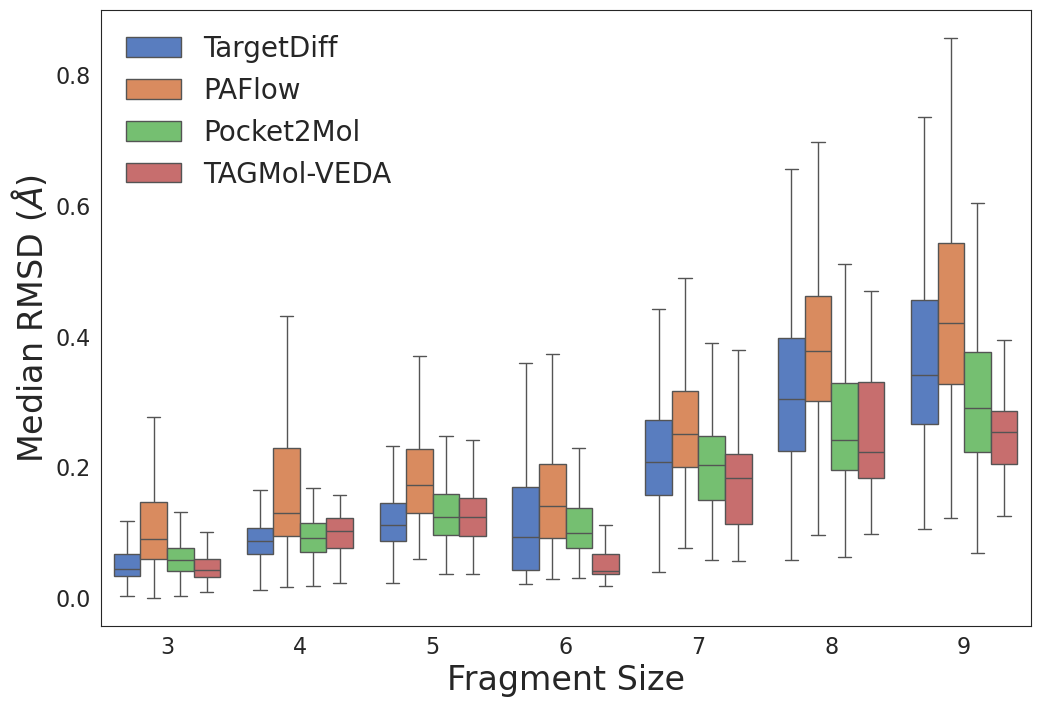

In [36]:
def construct_df(rigid_dict):
    df = []
    for k, all_v in rigid_dict.items():
        for v in all_v:
            df.append({'f_size': k, 'rmsd': v})
    return pd.DataFrame(df)

# sns.set(style="darkgrid")
sns.set_style("white")
sns.set_palette("muted")

tmp_1 = construct_df(ours_rigid_rmsd)
tmp_1['model'] = MODEL_NAME
tmp_2 = construct_df(paflow_rigid_rmsd)
tmp_2['model'] = 'PAFlow'
tmp_3 = construct_df(pocket2mol_rigid_rmsd)
tmp_3['model'] = 'Pocket2Mol'
tmp_4 = construct_df(targetdiff_rigid_rmsd)
tmp_4['model'] = 'TargetDiff'

viz_df = pd.concat([tmp_1, tmp_2, tmp_3, tmp_4]).reset_index()
viz_df = viz_df.query('3<=f_size<=9')

LABEL_FONTSIZE = 24
TICK_FONTSIZE = 16
LEGEND_FONTSIZE = 20
plt.figure(figsize=(12, 8))
sns.boxplot(x='f_size', y='rmsd', hue='model', data=viz_df, hue_order=('TargetDiff', 'PAFlow', 'Pocket2Mol', MODEL_NAME), showfliers = False)
plt.xlabel('Fragment Size', fontsize=LABEL_FONTSIZE)
plt.ylabel('Median RMSD ($\AA{}$)', fontsize=LABEL_FONTSIZE)
plt.xticks(fontsize=TICK_FONTSIZE)
plt.yticks(fontsize=TICK_FONTSIZE)
plt.legend(frameon=False, fontsize=LEGEND_FONTSIZE)
# plt.savefig('output_figures/rigid_rmsd.pdf')
plt.show()

# Vina Score

In [37]:
our_vina = np.array([np.median([v['vina']['dock'][0]['affinity'] for v in pocket]) for pocket in Globals.our_results])
paflow_vina = np.array([np.median([v['vina']['dock'][0]['affinity'] for v in pocket]) if len(pocket) > 0 else 0. for pocket in Globals.PAFlow_results])
pocket2mol_vina = np.array([np.median([v['vina']['dock'][0]['affinity'] for v in pocket]) for pocket in Globals.pocket2mol_results])
targetdiff_vina = np.array([np.median([v['vina']['dock'][0]['affinity'] for v in pocket]) for pocket in Globals.targetdiff_results])


In [38]:
all_vina = np.stack([our_vina, paflow_vina, pocket2mol_vina, targetdiff_vina], axis=0)
best_vina_idx = np.argmin(all_vina, axis=0)

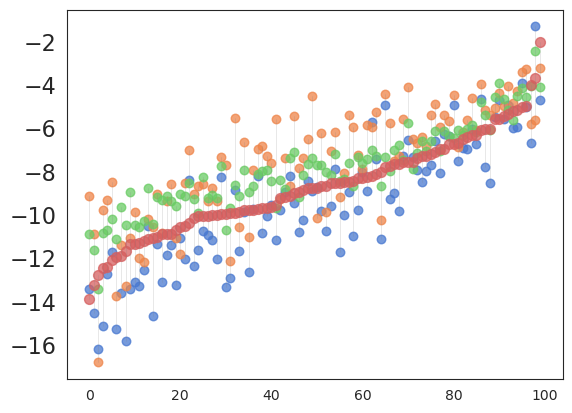

In [40]:
n_data = len(our_vina)
fig1_idx = np.argsort(our_vina)
ALPHA = 0.75
POINT_SIZE = 50
plt.scatter(np.arange(n_data), paflow_vina[fig1_idx], label=f'PAFlow (lowest in {np.mean(best_vina_idx==1)*100:.0f}%)', alpha=ALPHA, s=POINT_SIZE * 0.75)
plt.scatter(np.arange(n_data), pocket2mol_vina[fig1_idx], label=f'Pocket2Mol (lowest in {np.mean(best_vina_idx==2)*100:.0f}%)', alpha=ALPHA, s=POINT_SIZE * 0.75)
plt.scatter(np.arange(n_data), targetdiff_vina[fig1_idx], label=f'TargetDiff (lowest in {np.mean(best_vina_idx==3)*100:.0f}%)', alpha=ALPHA, s=POINT_SIZE * 0.75)
plt.scatter(np.arange(n_data), our_vina[fig1_idx], label=f'{MODEL_NAME} (lowest in {np.mean(best_vina_idx==0)*100:.0f}%)', alpha=ALPHA, s=POINT_SIZE)

# plt.xticks([])
plt.yticks(fontsize=16)
for i in range(n_data):
    plt.plot([i, i], [
        np.min([our_vina[fig1_idx][i], paflow_vina[fig1_idx][i], pocket2mol_vina[fig1_idx][i], targetdiff_vina[fig1_idx][i]]),
        np.max([our_vina[fig1_idx][i], paflow_vina[fig1_idx][i], pocket2mol_vina[fig1_idx][i], targetdiff_vina[fig1_idx][i]]),
    ], c='gray', linewidth=0.5, alpha=0.25)
